In [2]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from ultralytics import YOLO
from tqdm.notebook import tqdm
from datetime import datetime

# --- CONFIGURACIÓN DE HARDWARE ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Hardware activo: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# --- RUTAS ---
# Ajustado a tu estructura: notebooks/03_caracteres/ -> datasets/03_caracteres/
PROJECT_ROOT = '../../'
DATASET_DIR = os.path.join(PROJECT_ROOT, 'datasets/03_caracteres')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models/03_caracteres')

os.makedirs(MODELS_DIR, exist_ok=True)

# --- PARÁMETROS GLOBALES ---
IMG_SIZE = 64        # Tamaño para caracteres
BATCH_SIZE = 64
EPOCHS_YOLO = 50     # Ajusta según necesites
EPOCHS_CNN = 50

print(f"Dataset ubicado en: {os.path.abspath(DATASET_DIR)}")
print(f"Modelos se guardarán en: {os.path.abspath(MODELS_DIR)}")

Hardware activo: cuda
GPU: NVIDIA GeForce RTX 4070 Ti
Dataset ubicado en: /home/roberto/moca_proyecto/datasets/03_caracteres
Modelos se guardarán en: /home/roberto/moca_proyecto/models/03_caracteres


In [3]:
# Transformaciones para la CNN Custom
transform_cnn = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Cargar estructura de carpetas
train_dir = os.path.join(DATASET_DIR, 'train')
val_dir = os.path.join(DATASET_DIR, 'val')

if not os.path.exists(train_dir):
    raise FileNotFoundError(f"No se encuentra {train_dir}")

# Usamos ImageFolder para obtener clases y loaders para la CNN
train_dataset = datasets.ImageFolder(train_dir, transform=transform_cnn)
val_dataset = datasets.ImageFolder(val_dir, transform=transform_cnn)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# Información de Clases
CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"Datos cargados:")
print(f"   - Clases: {NUM_CLASSES}")
print(f"   - Imágenes Train: {len(train_dataset)}")
print(f"   - Imágenes Val: {len(val_dataset)}")

Datos cargados:
   - Clases: 37
   - Imágenes Train: 198343
   - Imágenes Val: 49709


In [5]:
class CustomOCR_CNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomOCR_CNN, self).__init__()
        
        # Bloque 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # 64 -> 32
        )
        
        # Bloque 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # 32 -> 16
        )
        
        # Bloque 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # 16 -> 8
        )
        
        # Clasificador
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512), 
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

print("Arquitectura CustomOCR_CNN definida en memoria.")

Arquitectura CustomOCR_CNN definida en memoria.


In [15]:
def train_yolo_classifier(model_name, run_name, epochs=50):
    """
    Entrena cualquier variante de YOLO (v8n, v8s, v11n, etc.)
    model_name: ej 'yolov8s-cls.pt'
    """
    print(f"\n🚀 Iniciando entrenamiento {model_name}: {run_name}")
    
    # Carga dinámica del modelo solicitado
    model = YOLO(model_name) 
    
    start_time = time.time()
    
    results = model.train(
        data=DATASET_DIR,
        project=MODELS_DIR,
        name=run_name,
        epochs=epochs,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        pretrained=True,
        verbose=True
    )
    
    duration = time.time() - start_time
    print(f"🏁 {model_name} finalizado en {duration:.2f} s")
    
    return {
        'model_name': model_name, # Guardamos el nombre para la gráfica
        'model_obj': model,
        'train_time': duration,
        'save_dir': results.save_dir
    }

def train_custom_cnn(run_name, epochs=50):
    """Entrena la CNN Custom y retorna el modelo y tiempo."""
    print(f"\nIniciando entrenamiento Custom CNN: {run_name}")
    
    model = CustomOCR_CNN(num_classes=NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        # Barra de progreso simple para no saturar el log
        pbar = tqdm(train_loader, desc=f"Ep {epoch+1}/{epochs}", leave=False)
        
        for inputs, labels in pbar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            # Métricas rápidas
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            running_loss += loss.item()
            pbar.set_postfix({'acc': f'{correct/total:.2f}'})
            
    duration = time.time() - start_time
    print(f"CNN finalizada en {duration:.2f} s")
    
    # Guardar pesos
    save_path = os.path.join(MODELS_DIR, f"{run_name}.pth")
    torch.save(model.state_dict(), save_path)
    
    return {
        'model_obj': model,
        'train_time': duration,
        'save_path': save_path
    }

In [7]:
def benchmark_models(yolo_model, cnn_model, cnn_loader):
    """Compara ambos modelos en el set de validación."""
    results = []
    
    # --- 1. EVALUAR YOLO ---
    print("\nEvaluando YOLOv8n-CLS...")
    # YOLO tiene validación interna optimizada
    y_metrics = yolo_model.val(split='val')
    
    y_acc = y_metrics.top1
    # speed contiene {'preprocess', 'inference', 'postprocess'} en ms/img
    y_latency = y_metrics.speed['inference'] 
    
    results.append({
        'Modelo': 'YOLOv8n-CLS',
        'Accuracy': y_acc,
        'Latencia (ms)': y_latency,
        'FPS': 1000/y_latency if y_latency > 0 else 0
    })
    
    # --- 2. EVALUAR CUSTOM CNN ---
    print("\nEvaluando Custom CNN...")
    cnn_model.eval()
    correct = 0
    total = 0
    inference_times = []
    
    # Warmup GPU
    if torch.cuda.is_available():
        dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
        for _ in range(50): _ = cnn_model(dummy)
        torch.cuda.synchronize()

    with torch.no_grad():
        for inputs, labels in tqdm(cnn_loader, desc="Benchmarking CNN"):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            # Medir tiempo de inferencia pura
            if torch.cuda.is_available(): torch.cuda.synchronize()
            start = time.time()
            
            outputs = cnn_model(inputs)
            
            if torch.cuda.is_available(): torch.cuda.synchronize()
            end = time.time()
            
            # Calcular latencia por imagen (batch time / batch size)
            batch_time_ms = (end - start) * 1000
            inference_times.append(batch_time_ms / inputs.size(0))
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    c_acc = correct / total
    c_latency = sum(inference_times) / len(inference_times)
    
    results.append({
        'Modelo': 'Custom CNN',
        'Accuracy': c_acc,
        'Latencia (ms)': c_latency,
        'FPS': 1000/c_latency if c_latency > 0 else 0
    })
    
    return pd.DataFrame(results)

In [8]:
# Nombres de experimento
date_str = datetime.now().strftime('%Y%m%d')
run_yolo = f"{date_str}_yolo_v8n_chars"
run_cnn = f"{date_str}_custom_cnn_chars"

# 1. Entrenar YOLO
yolo_results = train_yolo_classifier(run_yolo, epochs=EPOCHS_YOLO)

# 2. Entrenar CNN
cnn_results = train_custom_cnn(run_cnn, epochs=EPOCHS_CNN)

# Guardar tiempos de entrenamiento para el reporte final
train_times = {
    'YOLOv8n-CLS': yolo_results['train_time'],
    'Custom CNN': cnn_results['train_time']
}


Iniciando entrenamiento YOLO: 20251217_yolo_v8n_chars
New https://pypi.org/project/ultralytics/8.3.240 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.233 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11852MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../datasets/03_caracteres, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.9

Ep 1/50:   0%|          | 0/3100 [00:00<?, ?it/s]

Ep 2/50:   0%|          | 0/3100 [00:00<?, ?it/s]

Ep 3/50:   0%|          | 0/3100 [00:00<?, ?it/s]

Ep 4/50:   0%|          | 0/3100 [00:00<?, ?it/s]

...

Ep 47/50:   0%|          | 0/3100 [00:00<?, ?it/s]

Ep 48/50:   0%|          | 0/3100 [00:00<?, ?it/s]

Ep 49/50:   0%|          | 0/3100 [00:00<?, ?it/s]

Ep 50/50:   0%|          | 0/3100 [00:00<?, ?it/s]

CNN finalizada en 861.40 s



Evaluando YOLOv8n-CLS...
Ultralytics 8.3.233 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11852MiB)
train: /home/roberto/moca_proyecto/datasets/03_caracteres/train... found 198343 images in 37 classes ✅ 
val: /home/roberto/moca_proyecto/datasets/03_caracteres/val... found 49709 images in 37 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 64.2±21.7 MB/s, size: 0.9 KB)
val: Scanning /home/roberto/moca_proyecto/datasets/03_caracteres/val... 49709 images, 0 corrupt: 100% ━━━━━━━━━━━━ 49709/49709 123.2Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3107/3107 415.1it/s 7.5s0.1s
                   all      0.963          1
Speed: 0.0ms preprocess, 0.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /home/roberto/moca_proyecto/notebooks/03_caracteres/runs/classify/val16

Evaluando Custom CNN...


Benchmarking CNN:   0%|          | 0/777 [00:00<?, ?it/s]


TABLA FINAL DE RESULTADOS:


,Modelo,Accuracy,Latencia (ms),FPS,Tiempo Entrenamiento (s)
0,YOLOv8n-CLS,0.962864,0.127435,7847.127815,2593.082412
1,Custom CNN,0.988392,0.013689,73053.084189,861.396299


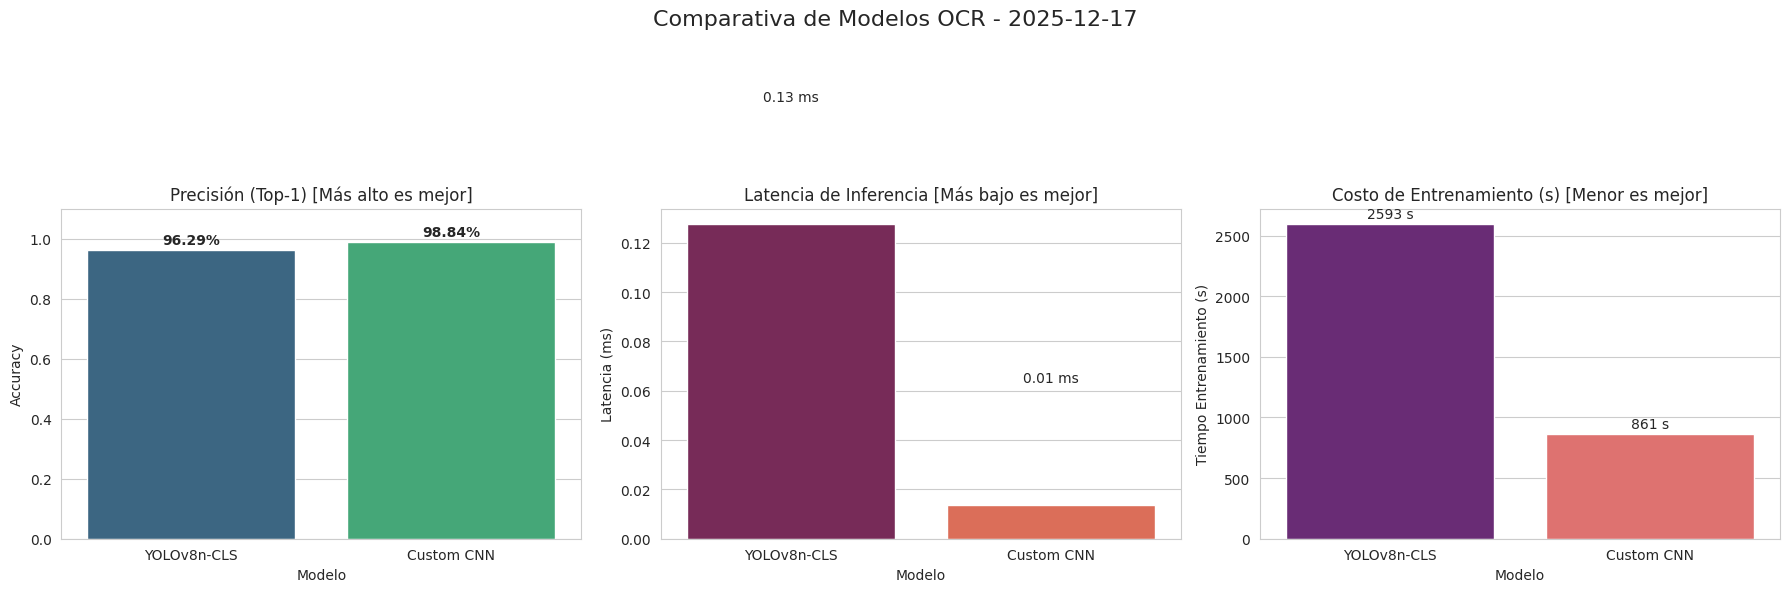

In [14]:
%matplotlib inline
from IPython.display import display # Importación explícita para asegurar que la tabla se vea

# 1. Ejecutar Benchmark
# Aseguramos que los modelos estén en memoria
if 'yolo_results' not in locals() or 'cnn_results' not in locals():
    print("ALERTA: No se encuentran los resultados de entrenamiento.")
    print("   Por favor ejecuta la Celda 6 primero.")
else:
    df_bench = benchmark_models(
        yolo_model=yolo_results['model_obj'], 
        cnn_model=cnn_results['model_obj'], 
        cnn_loader=val_loader
    )

    # 2. Agregar tiempos de entrenamiento
    # Mapeamos los tiempos guardados previamente
    df_bench['Tiempo Entrenamiento (s)'] = df_bench['Modelo'].map(train_times)

    # 3. MOSTRAR TABLA
    print("\nTABLA FINAL DE RESULTADOS:")
    try:
        display(df_bench) # Intento primario (formato bonito)
    except:
        print(df_bench)   # Fallback (formato texto plano)

    # --- VISUALIZACIÓN ---
    # Configuración de estilo para evitar advertencias futuras
    sns.set_style("whitegrid")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'Comparativa de Modelos OCR - {datetime.now().strftime("%Y-%m-%d")}', fontsize=16)

    # Gráfica 1: Precisión
    # CORRECCIÓN: Agregamos hue='Modelo' y legend=False como pide la advertencia
    sns.barplot(data=df_bench, x='Modelo', y='Accuracy', hue='Modelo', ax=axes[0], palette='viridis', legend=False)
    axes[0].set_ylim(0, 1.1)
    axes[0].set_title('Precisión (Top-1) [Más alto es mejor]')
    for i, v in enumerate(df_bench['Accuracy']):
        axes[0].text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

    # Gráfica 2: Latencia
    sns.barplot(data=df_bench, x='Modelo', y='Latencia (ms)', hue='Modelo', ax=axes[1], palette='rocket', legend=False)
    axes[1].set_title('Latencia de Inferencia [Más bajo es mejor]')
    for i, v in enumerate(df_bench['Latencia (ms)']):
        axes[1].text(i, v + 0.05, f"{v:.2f} ms", ha='center')

    # Gráfica 3: Tiempo Entrenamiento
    sns.barplot(data=df_bench, x='Modelo', y='Tiempo Entrenamiento (s)', hue='Modelo', ax=axes[2], palette='magma', legend=False)
    axes[2].set_title('Costo de Entrenamiento (s) [Menor es mejor]')
    for i, v in enumerate(df_bench['Tiempo Entrenamiento (s)']):
        axes[2].text(i, v + 50, f"{int(v)} s", ha='center')

    plt.tight_layout()
    plt.show()

In [16]:
# Entrenar YOLOv8 Small
run_v8s = f"{date_str}_yolo_v8s_chars"

# Nota: Se descargará yolov8s-cls.pt automáticamente si no lo tienes
result_v8s = train_yolo_classifier('yolov8s-cls.pt', run_v8s, epochs=EPOCHS_YOLO)


🚀 Iniciando entrenamiento yolov8s-cls.pt: 20251217_yolo_v8s_chars
New https://pypi.org/project/ultralytics/8.3.240 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.233 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11852MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../datasets/03_caracteres, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, 

In [17]:
# Entrenar YOLOv8 Medium
run_v8m = f"{date_str}_yolo_v8m_chars"

result_v8m = train_yolo_classifier('yolov8m-cls.pt', run_v8m, epochs=EPOCHS_YOLO)


🚀 Iniciando entrenamiento yolov8m-cls.pt: 20251217_yolo_v8m_chars
New https://pypi.org/project/ultralytics/8.3.240 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.233 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11852MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../datasets/03_caracteres, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-cls.pt, 

In [18]:
# Entrenar YOLO11 Nano
run_v11n = f"{date_str}_yolo_11n_chars"

result_v11n = train_yolo_classifier('yolo11n-cls.pt', run_v11n, epochs=EPOCHS_YOLO)


🚀 Iniciando entrenamiento yolo11n-cls.pt: 20251217_yolo_11n_chars
New https://pypi.org/project/ultralytics/8.3.240 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.233 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11852MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../datasets/03_caracteres, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, 


⚔️ INICIANDO TORNEO DE 5 MODELOS ⚔️


Eval Custom CNN:   0%|          | 0/777 [00:00<?, ?it/s]

Eval YOLOv8n (YOLO)...
Ultralytics 8.3.233 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11852MiB)
train: /home/roberto/moca_proyecto/datasets/03_caracteres/train... found 198343 images in 37 classes ✅ 
val: /home/roberto/moca_proyecto/datasets/03_caracteres/val... found 49709 images in 37 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 67.2±25.3 MB/s, size: 0.9 KB)
val: Scanning /home/roberto/moca_proyecto/datasets/03_caracteres/val... 49709 images, 0 corrupt: 100% ━━━━━━━━━━━━ 49709/49709 111.3Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3107/3107 415.1it/s 7.5s<0.0s
                   all      0.963          1
Speed: 0.0ms preprocess, 0.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /home/roberto/moca_proyecto/notebooks/03_caracteres/runs/classify/val17
Eval YOLOv8s (YOLO)...
Ultralytics 8.3.233 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11852MiB)
YO

,Modelo,Accuracy,Latencia (ms),FPS,Tiempo Train (s)
0,Custom CNN,0.988392,0.014028,71284.747549,861.396299
3,YOLOv8m,0.969342,0.169842,5887.815130,3428.140457
2,YOLOv8s,0.966726,0.129035,7749.859858,2624.717929
1,YOLOv8n,0.962864,0.127140,7865.344661,2593.082412
4,YOLO11n,0.962260,0.173842,5752.364697,3538.018579


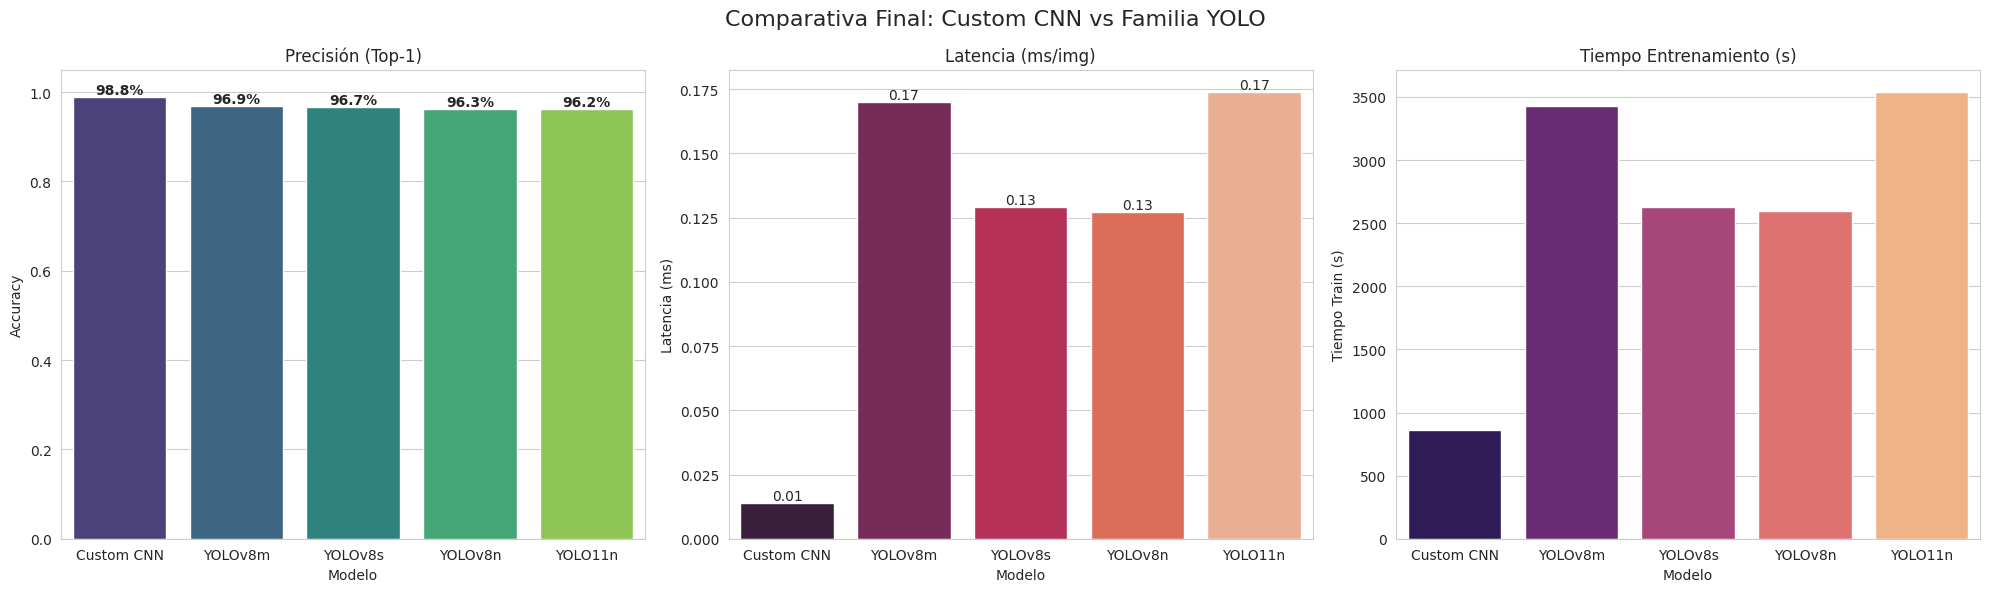

In [19]:
# Lista de resultados disponibles (Asegúrate de haber corrido las celdas anteriores)
# Asumimos que 'cnn_results' y 'yolo_results' (v8n) vienen de tu ejecución previa
all_trained_models = []

# Agregar CNN (Si existe en memoria)
if 'cnn_results' in locals(): 
    all_trained_models.append({'label': 'Custom CNN', 'res': cnn_results})

# Agregar YOLOs (Si existen en memoria)
if 'yolo_results' in locals(): 
    all_trained_models.append({'label': 'YOLOv8n', 'res': yolo_results})
if 'result_v8s' in locals(): 
    all_trained_models.append({'label': 'YOLOv8s', 'res': result_v8s})
if 'result_v8m' in locals(): 
    all_trained_models.append({'label': 'YOLOv8m', 'res': result_v8m})
if 'result_v11n' in locals(): 
    all_trained_models.append({'label': 'YOLO11n', 'res': result_v11n})

# --- BENCHMARK GLOBAL ---
global_results = []

print(f"\n⚔️ INICIANDO TORNEO DE {len(all_trained_models)} MODELOS ⚔️")

for item in all_trained_models:
    label = item['label']
    res_obj = item['res']
    
    # Lógica para evaluar (Diferente si es CNN o YOLO)
    if label == 'Custom CNN':
        # Tu lógica manual para CNN
        model = res_obj['model_obj']
        model.eval()
        inference_times = []
        correct = 0; total = 0
        
        # Warmup
        if torch.cuda.is_available():
            dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
            for _ in range(20): _ = model(dummy)
            torch.cuda.synchronize()
            
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Eval {label}"):
                inputs = inputs.to(DEVICE); labels = labels.to(DEVICE)
                if torch.cuda.is_available(): torch.cuda.synchronize()
                
                t0 = time.time()
                outputs = model(inputs)
                if torch.cuda.is_available(): torch.cuda.synchronize()
                t1 = time.time()
                
                inference_times.append((t1-t0)*1000 / inputs.size(0))
                _, pred = outputs.max(1)
                total += labels.size(0)
                correct += pred.eq(labels).sum().item()
        
        acc = correct/total
        lat = sum(inference_times)/len(inference_times)
        
    else:
        # Lógica nativa para YOLOs
        print(f"Eval {label} (YOLO)...")
        y_model = res_obj['model_obj']
        metrics = y_model.val(split='val', verbose=False)
        acc = metrics.top1
        lat = metrics.speed['inference']
    
    global_results.append({
        'Modelo': label,
        'Accuracy': acc,
        'Latencia (ms)': lat,
        'FPS': 1000/lat if lat > 0 else 0,
        'Tiempo Train (s)': res_obj.get('train_time', 0) # .get por si acaso
    })

# --- VISUALIZACIÓN FINAL ---
df_final = pd.DataFrame(global_results).sort_values(by='Accuracy', ascending=False)

print("\n🏆 TABLA DE POSICIONES:")
from IPython.display import display
display(df_final)

# Gráficas
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Comparativa Final: Custom CNN vs Familia YOLO', fontsize=16)

# Accuracy
sns.barplot(data=df_final, x='Modelo', y='Accuracy', hue='Modelo', ax=ax[0], palette='viridis', legend=False)
ax[0].set_ylim(0, 1.05)
ax[0].set_title('Precisión (Top-1)')
for i, v in enumerate(df_final['Accuracy']):
    ax[0].text(i, v, f"{v:.1%}", ha='center', va='bottom', fontweight='bold')

# Latency
sns.barplot(data=df_final, x='Modelo', y='Latencia (ms)', hue='Modelo', ax=ax[1], palette='rocket', legend=False)
ax[1].set_title('Latencia (ms/img)')
for i, v in enumerate(df_final['Latencia (ms)']):
    ax[1].text(i, v, f"{v:.2f}", ha='center', va='bottom')

# Train Time
sns.barplot(data=df_final, x='Modelo', y='Tiempo Train (s)', hue='Modelo', ax=ax[2], palette='magma', legend=False)
ax[2].set_title('Tiempo Entrenamiento (s)')

plt.tight_layout()
display(fig)
plt.close(fig)